In [1]:
import numpy as np
import pandas as pd

In [3]:
from google.colab import files
upload = files.upload()

Saving Restaurant_Reviews.tsv to Restaurant_Reviews.tsv


In [5]:
df=pd.read_csv('Restaurant_Reviews.tsv',delimiter='\t', quoting=3)
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [7]:
df.shape

(1000, 2)

In [9]:
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
corpus = []
for i in range(0,1000):
  # Cleaning special character from the reviews
  review = re.sub(pattern='[^a-zA-Z]',repl=' ', string=df['Review'][i])
  # Converting the entire review into lower case
  review = review.lower()
  # Tokenizing the review by words
  review_words = review.split()
  # Removing the stop words
  review_words = [word for word in review_words if not word in set(stopwords.words('english'))]
  # Stemming the words
  ps = PorterStemmer()
  review = [ps.stem(word) for word in review_words]
  # Joining the stemmed words
  review = ' '.join(review)
  # Creating a corpus
  corpus.append(review)

corpus[0:10]

['wow love place',
 'crust good',
 'tasti textur nasti',
 'stop late may bank holiday rick steve recommend love',
 'select menu great price',
 'get angri want damn pho',
 'honeslti tast fresh',
 'potato like rubber could tell made ahead time kept warmer',
 'fri great',
 'great touch']

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, 1].values

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.20, random_state = 0)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=35)
model.fit(X_train, y_train)
# RandomForestClassifier(n_estimators=35) # This line was redundant
model.score(X_test, y_test)

0.72

In [17]:
y_pred = model.predict(X_test) # Accuracy, Precision and Recall from sklearn.metrics import accuracy_score from sklearn.metrics import precision_score from sklearn.metrics import recall_score score1 = accuracy_score(y_test,y_pred) score2 = precision_score(y_test,y_pred) score3= recall_score(y_test,y_pred) print("---- Scores ---- ") print("Accuracy score is: {}%".format(round(score1*100,2))) print("Precision score is: {}".format(round(score2,2))) print("Recall score is: {}".format(round(score3,2)))

Text(33.222222222222214, 0.5, 'Actual values')

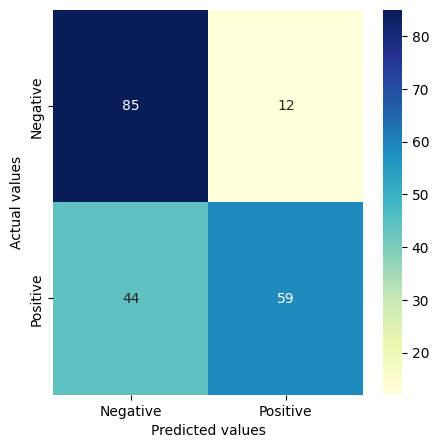

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize = (5,5))
sns.heatmap(cm, annot=True, cmap="YlGnBu", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted values')
plt.ylabel('Actual values')

In [20]:
# Hyperparameter tuning the Naive Bayes Classifierbest_accuracy = 0.0 n_estimators = 5 for i in np.arange(1,30,2): temp_classifier = RandomForestClassifier(n_estimators=i) temp_classifier.fit(X_train, y_train) temp_y_pred = temp_classifier.predict(X_test) score = accuracy_score(y_test, temp_y_pred) print("Accuracy score for n_estimators={} is: {}%".format(round(i,1), round(score*100,2)))if score>best_accuracy: best_accuracy = score n_estimators_val = i print(' ') print('The best accuracy is {}% with n_estimators value as {}'.format(round(best_accuracy*100, 2), round(n_estimators_val,1)))